In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

In [97]:
PATH = "../Results/alns_metrics.csv"
df_completo = pd.read_csv(PATH)

best_veh = df_completo['best_veh'].idxmin()
best_veh_iter = df_completo.loc[best_veh, 'iter']

df_completo['best_global_cost'] = (df_completo['best_veh'] * 10000.0) + df_completo['best_dist']

best_index = df_completo['best_global_cost'].idxmin()
best_iter = df_completo.loc[best_index, 'iter']

cutoff_idx = min(best_index + 5, len(df_completo))

df = df_completo.iloc[:cutoff_idx].copy()
print(f"Óptimo encontrado en la iteración: {df_completo.loc[best_index, 'iter']}")
print(f"Recortando gráfica a {len(df)} filas para mejorar legibilidad.")

Óptimo encontrado en la iteración: 30
Recortando gráfica a 35 filas para mejorar legibilidad.


# Comportamiento del ALNS
---

### Convergencia de la función objetivo $f_1$

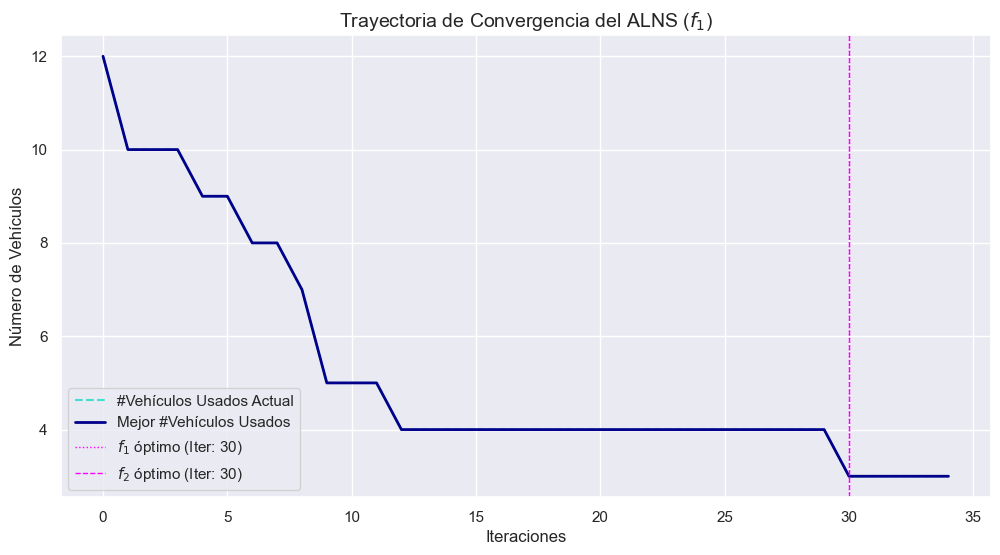

In [98]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='iter', y='curr_veh', color='turquoise', alpha=1, label='#Vehículos Usados Actual', linestyle='--')
sns.lineplot(data=df, x='iter', y='best_veh', color='darkblue', linewidth=2, label='Mejor #Vehículos Usados')

plt.axvline(x=best_veh_iter, color='magenta', linestyle=':', linewidth=1, label=f'$f_1$ óptimo (Iter: {best_veh_iter})')
plt.axvline(x=best_iter, color='magenta', linestyle='--', linewidth=1, label=f'$f_2$ óptimo (Iter: {best_iter})')

plt.title('Trayectoria de Convergencia del ALNS ($f_1$)', fontsize=14)
plt.xlabel('Iteraciones')
plt.ylabel('Número de Vehículos')
plt.legend()
plt.show()

### Convergencia de la función objetivo $f_2$

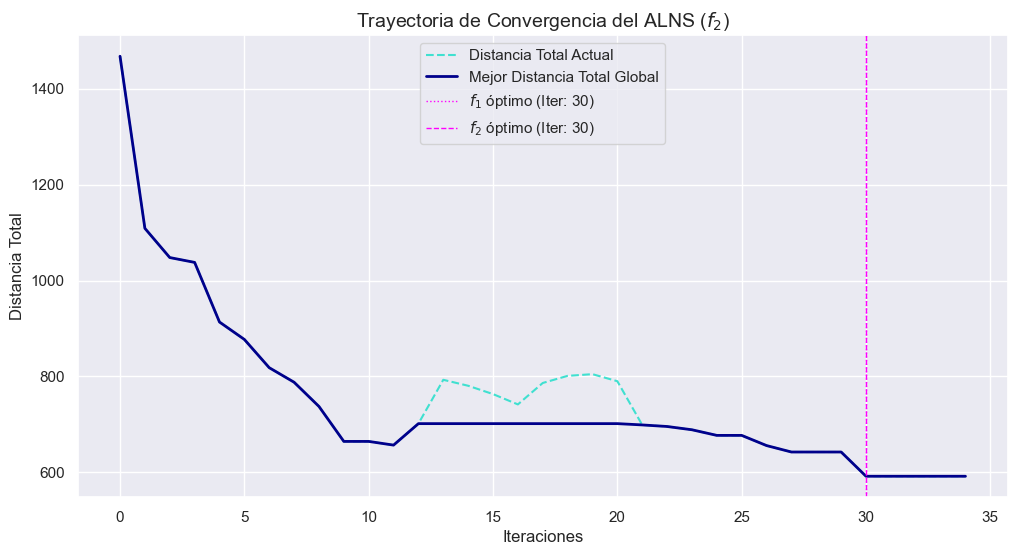

In [99]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='iter', y='curr_dist', color='turquoise', alpha=1, label='Distancia Total Actual', linestyle='--')
sns.lineplot(data=df, x='iter', y='best_dist', color='darkblue', linewidth=2, label='Mejor Distancia Total Global')

plt.axvline(x=best_veh_iter, color='magenta', linestyle=':', linewidth=1, label=f'$f_1$ óptimo (Iter: {best_veh_iter})')
plt.axvline(x=best_iter, color='magenta', linestyle='--', linewidth=1, label=f'$f_2$ óptimo (Iter: {best_iter})')

plt.title('Trayectoria de Convergencia del ALNS ($f_2$)', fontsize=14)
plt.xlabel('Iteraciones')
plt.ylabel('Distancia Total')
plt.legend()
plt.show()

### Evolución de Pesos $\rho^-$

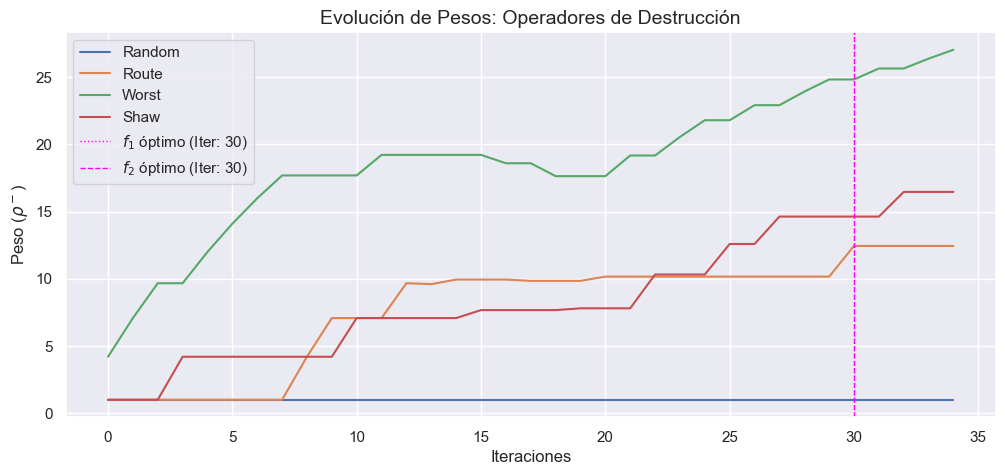

In [100]:
d_cols = [c for c in df.columns if 'd_weight' in c]
d_names = ['Random', 'Route', 'Worst', 'Shaw']

plt.figure(figsize=(12, 5))
for col, name in zip(d_cols, d_names):
    sns.lineplot(data=df, x='iter', y=col, label=name)

plt.axvline(x=best_veh_iter, color='magenta', linestyle=':', linewidth=1, label=f'$f_1$ óptimo (Iter: {best_veh_iter})')
plt.axvline(x=best_iter, color='magenta', linestyle='--', linewidth=1, label=f'$f_2$ óptimo (Iter: {best_iter})')

plt.title('Evolución de Pesos: Operadores de Destrucción', fontsize=14)
plt.xlabel('Iteraciones')
plt.ylabel('Peso ($\\rho^-$)')
plt.legend()
plt.show()

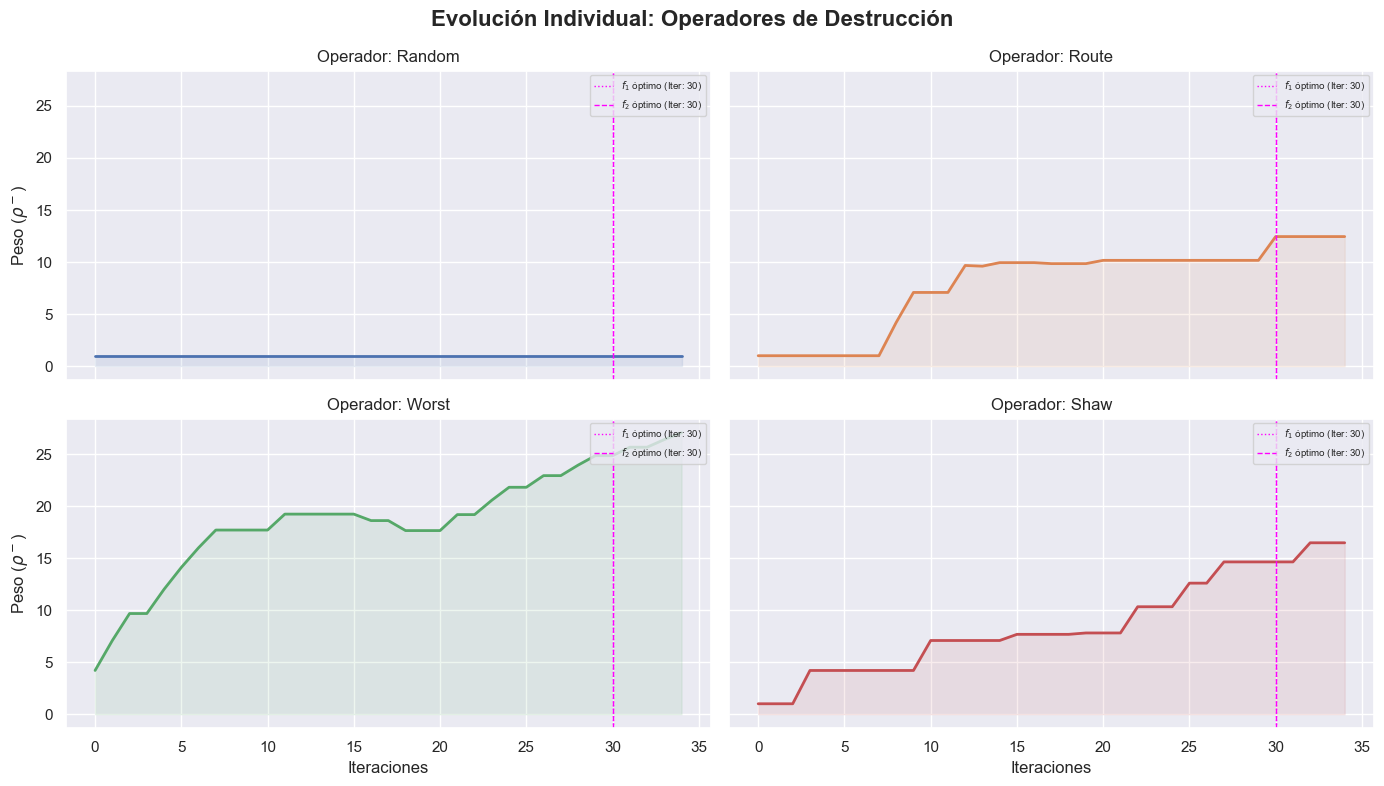

In [101]:
d_cols = [c for c in df.columns if 'd_weight' in c]
d_names = ['Random', 'Route', 'Worst', 'Shaw']

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
fig.suptitle('Evolución Individual: Operadores de Destrucción', fontsize=16, fontweight='bold')

axes = axes.flatten()

colores = sns.color_palette()

for i, (col, name) in enumerate(zip(d_cols, d_names)):
    sns.lineplot(data=df, x='iter', y=col, ax=axes[i], color=colores[i], linewidth=2)
    axes[i].set_title(f'Operador: {name}')
    axes[i].set_ylabel('Peso ($\\rho^-$)')

    axes[i].fill_between(df['iter'], df[col], alpha=0.1, color=colores[i])
    axes[i].axvline(x=best_veh_iter, color='magenta', linestyle=':', linewidth=1, label=f'$f_1$ óptimo (Iter: {best_veh_iter})')
    axes[i].axvline(x=best_iter, color='magenta', linestyle='--', linewidth=1, label=f'$f_2$ óptimo (Iter: {best_iter})')
    axes[i].legend(loc='upper right', fontsize=7)

axes[2].set_xlabel('Iteraciones')
axes[3].set_xlabel('Iteraciones')

plt.tight_layout()
plt.show()

### Evolución de pesos $\rho^+$

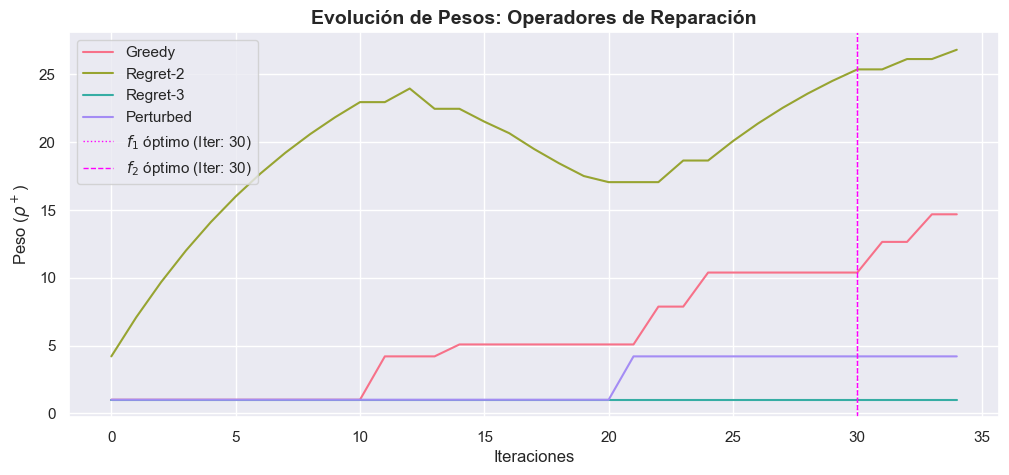

In [102]:
r_cols = [c for c in df.columns if 'r_weight' in c]
r_names = ['Greedy', 'Regret-2', 'Regret-3', 'Perturbed']

colores_repair = sns.color_palette("husl", 4)

plt.figure(figsize=(12, 5))
for i, (col, name) in enumerate(zip(r_cols, r_names)):
    sns.lineplot(data=df, x='iter', y=col, label=name, color=colores_repair[i])

plt.axvline(x=best_veh_iter, color='magenta', linestyle=':', linewidth=1, label=f'$f_1$ óptimo (Iter: {best_veh_iter})')
plt.axvline(x=best_iter, color='magenta', linestyle='--', linewidth=1, label=f'$f_2$ óptimo (Iter: {best_iter})')

plt.title('Evolución de Pesos: Operadores de Reparación', fontsize=14, fontweight='bold')
plt.xlabel('Iteraciones')
plt.ylabel('Peso ($\\rho^+$)')
plt.legend()
plt.show()

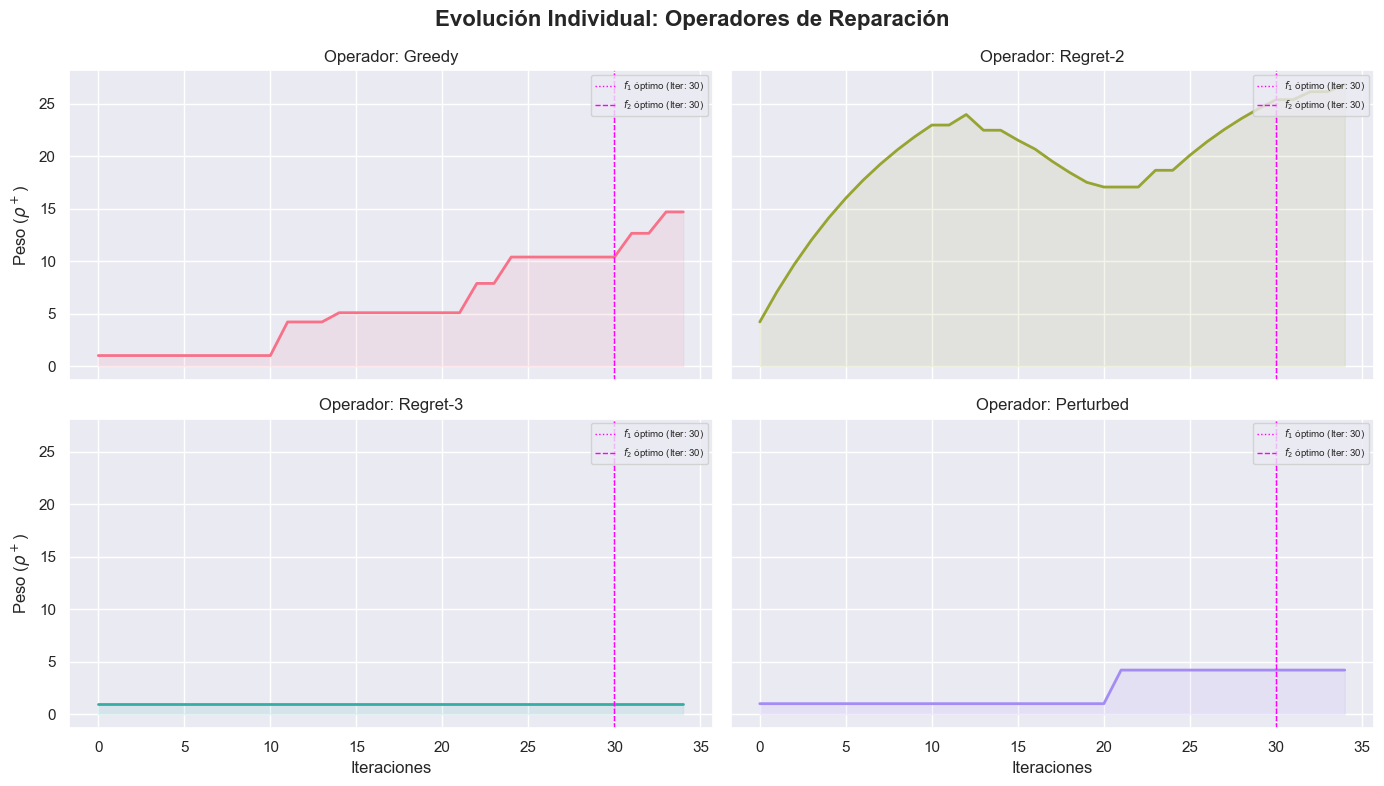

In [103]:
r_cols = [c for c in df.columns if 'r_weight' in c]
r_names = ['Greedy', 'Regret-2', 'Regret-3', 'Perturbed']

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
fig.suptitle('Evolución Individual: Operadores de Reparación', fontsize=16, fontweight='bold')

axes = axes.flatten()
colores_repair = sns.color_palette("husl", 4)

for i, (col, name) in enumerate(zip(r_cols, r_names)):
    sns.lineplot(data=df, x='iter', y=col, ax=axes[i], color=colores_repair[i], linewidth=2)
    axes[i].set_title(f'Operador: {name}')
    axes[i].set_ylabel('Peso ($\\rho^+$)')
    
    axes[i].fill_between(df['iter'], df[col], alpha=0.1, color=colores_repair[i])
    axes[i].axvline(x=best_veh_iter, color='magenta', linestyle=':', linewidth=1, label=f'$f_1$ óptimo (Iter: {best_veh_iter})')
    axes[i].axvline(x=best_iter, color='magenta', linestyle='--', linewidth=1, label=f'$f_2$ óptimo (Iter: {best_iter})')
    axes[i].legend(loc='upper right', fontsize=7)

axes[2].set_xlabel('Iteraciones')
axes[3].set_xlabel('Iteraciones')

plt.tight_layout()
plt.show()

### Sinergía de Operadores

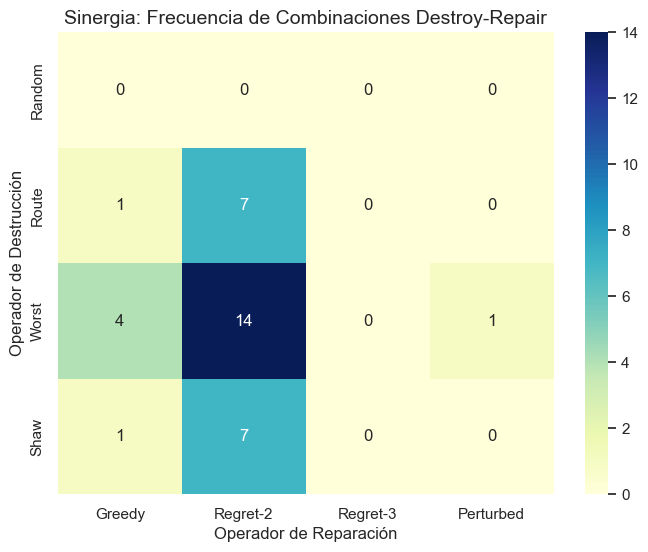

In [104]:
synergy_matrix = pd.crosstab(df['d_op'], df['r_op'])

synergy_matrix = synergy_matrix.reindex(index=[0, 1, 2, 3], columns=[0, 1, 2, 3], fill_value=0)

synergy_matrix.index = ['Random', 'Route', 'Worst', 'Shaw']
synergy_matrix.columns = ['Greedy', 'Regret-2', 'Regret-3', 'Perturbed']

plt.figure(figsize=(8, 6))
sns.heatmap(synergy_matrix, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Sinergia: Frecuencia de Combinaciones Destroy-Repair', fontsize=14)
plt.xlabel('Operador de Reparación')
plt.ylabel('Operador de Destrucción')
plt.show()

### Perfil Termodinámico

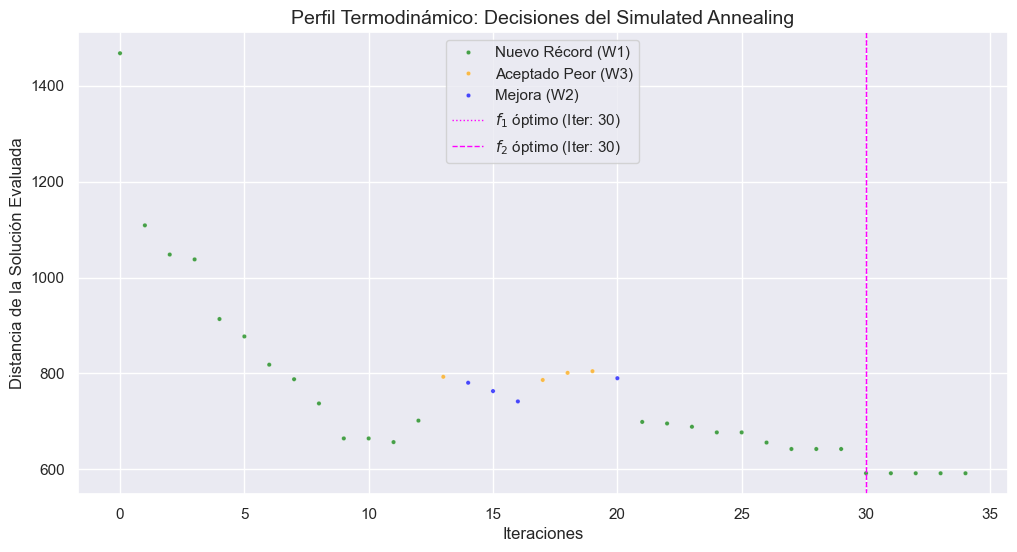

In [105]:
plt.figure(figsize=(12, 6))
score_map = {33.0: 'Nuevo Récord (W1)', 13.0: 'Mejora (W2)', 9.0: 'Aceptado Peor (W3)', 0.0: 'Rechazado (W4)'}
df['score_label'] = df['score'].map(score_map)

sns.scatterplot(data=df, x='iter', y='curr_dist', hue='score_label', 
                palette={'Nuevo Récord (W1)':'green', 'Mejora (W2)':'blue', 
                         'Aceptado Peor (W3)':'orange', 'Rechazado (W4)':'red'},
                s=10, alpha=0.7)

plt.axvline(x=best_veh_iter, color='magenta', linestyle=':', linewidth=1, label=f'$f_1$ óptimo (Iter: {best_veh_iter})')
plt.axvline(x=best_iter, color='magenta', linestyle='--', linewidth=1, label=f'$f_2$ óptimo (Iter: {best_iter})')

plt.title('Perfil Termodinámico: Decisiones del Simulated Annealing', fontsize=14)
plt.xlabel('Iteraciones')
plt.ylabel('Distancia de la Solución Evaluada')
plt.legend()
plt.show()